<a href="https://colab.research.google.com/github/Likhithaa-Guntaka/ai-skills-market-intelligence/blob/main/notebooks/03_analysis_and_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Title:** Tracking the AI Skills Revolution: How Demand for AI & Data Skills Is Changing

**Phase III — analytical questions and first visualizations.**

*Phase 1 framed this project as "(2022–Present)". The Adzuna `/search` endpoint returns only currently-listed postings, so historical coverage back to 2022 cannot be retrieved through it. This phase introduces pagination to 150 postings and establishes the five analytical questions using Matplotlib. Phase IV re-runs the same questions with refined, interactive visualizations — see `04_final_analysis.ipynb`.*

by Likhitha Guntaka


## **Project objective:** To analyze demand for AI and Data-related skills in **US** job postings, using two live data sources: the Adzuna Jobs API (US endpoint) and the Stack Overflow tags API.

*The two sources are described side by side; they are not merged into a single dataset in this analysis.*

## Data overview

| | Adzuna Jobs API | Stack Overflow (Stack Exchange) tags API |
|---|---|---|
| Endpoint | `/v1/api/jobs/us/search/{page}` — **US only** | `/2.3/tags` (`site=stackoverflow`, `sort=popular`) |
| Query | `"AI OR Data OR Machine Learning"`, 3 paginated pages | top 100 tags by all-time question volume |
| Observations | see the `Total jobs pulled` / `Rows:` output below | 100 tags |
| Time coverage | currently-listed postings only; see the monthly chart for the observed date range | all-time cumulative counts, **no date dimension** |
| Fields used | title, company, location, salary_min, salary_max, category, created, description | tag_name, question_count, has_synonyms |

### Original research questions vs. what the data allowed

| Phase 1 question | Status in this analysis |
|---|---|
| Growth in AI/data job demand | **Partly.** Postings are counted per month, but only across the short recent window the API returns, which cannot measure growth since 2022. |
| Salary differences between AI and non-AI technical roles | **Not possible.** The query retrieves only AI/Data postings, so there is no non-AI comparison group. |
| Skill keywords linked to demand and compensation | **Demand only, and weakly.** Keyword counts run against descriptions Adzuna truncates to ~500 characters. No keyword-to-salary analysis was performed. |
| Geographic hiring patterns | **Attempted, not conclusive.** Locations resolve to granular Adzuna locality names carrying very few postings each. |
| Developer interest in emerging AI technologies | **Not analyzed.** The tags endpoint returns all-time popular tags — general-purpose languages — and carries no dates. |
| Relationship between developer activity and employer demand | **Not demonstrated.** The two datasets are never joined and no statistical comparison is performed. |

## D1. Library imports

In [1]:
# Used to send requests to online APIs
import requests

# Used to store and manipulate data in tables (DataFrames)
import pandas as pd

# Used for numerical operations (like handling missing values)
import numpy as np

# Used to work with dates and timestamps
from datetime import datetime

##D2. Data pre-processing

### AP1-1: Adzuna (Jobs API)
**Connecting to Adzuna Jobs API**
* This API provides real job postings related to AI, Data, and Technology.
* The request uses the Adzuna **US** endpoint (`/jobs/us/`), so this is **US job posting data**, not global data.
* A city filter can be switched ON to narrow results to a single US location (for example New York or San Francisco). It is left OFF here, so results cover the US as a whole.


In [2]:
# CITY FILTER SWITCH
# False = US-wide results across the Adzuna US endpoint (default)
# True  = narrow the search to one US city / location
use_city_filter = False

# Any US location, e.g. "New York", "San Francisco", "Chicago"
city_name = "New York"

# Only need to change ONE word to switch


In [3]:
# Connect to Adzuna API

# Credentials are loaded from Colab Secrets (sidebar -> Secrets / key icon).
# Add ADZUNA_APP_ID and ADZUNA_APP_KEY there and enable notebook access.
# Outside Colab, set them as environment variables of the same name.
import os

try:
    from google.colab import userdata
    APP_ID = userdata.get("ADZUNA_APP_ID")
    APP_KEY = userdata.get("ADZUNA_APP_KEY")
except ImportError:
    APP_ID = os.environ["ADZUNA_APP_ID"]
    APP_KEY = os.environ["ADZUNA_APP_KEY"]

# Using US Adzuna endpoint for job market analysis
adzuna_url = "https://api.adzuna.com/v1/api/jobs/us/search/1"

# Parameters for the request
params = {
    "app_id": APP_ID,
    "app_key": APP_KEY,
    "results_per_page": 100,
    "what": "AI OR Data OR Machine Learning"
}

# If the city filter is ON, add location to the query
if use_city_filter:
    params["where"] = city_name

# Header to avoid being blocked
headers = {
    "User-Agent": "Mozilla/5.0"
}

# Send request to Adzuna
response = requests.get(adzuna_url, params=params, headers=headers)

# Confirm request success
# Redact credentials before printing so they never land in saved notebook output
safe_url = response.url.replace(APP_ID, "<APP_ID>").replace(APP_KEY, "<APP_KEY>")
print("Final URL:", safe_url)
print("Status Code:", response.status_code)
print("Using city filter:", use_city_filter)
print("Scope:", city_name if use_city_filter else "US-WIDE")

Final URL: https://api.adzuna.com/v1/api/jobs/us/search/1?app_id=<APP_ID>&app_key=<APP_KEY>&results_per_page=100&what=AI+OR+Data+OR+Machine+Learning
Status Code: 200
Using city filter: False
City: GLOBAL


In [4]:
# Pagination: Pull multiple pages of results

all_jobs = []

# Loop through first 3 pages (you can increase later)
for page in range(1, 4):   # pages 1, 2, 3
    url = f"https://api.adzuna.com/v1/api/jobs/us/search/{page}"
    response = requests.get(url, params=params)

    # Convert each page to JSON
    data = response.json()

    # Add job results from this page to master list
    for job in data.get("results", []):
        all_jobs.append(job)

# Convert to DataFrame
print("Total jobs pulled:", len(all_jobs))

adzuna_df = pd.DataFrame(all_jobs)

# Show a few rows
adzuna_df.head()

Total jobs pulled: 150


,adref,title,location,salary_max,latitude,__CLASS__,category,description,longitude,id,company,created,salary_min,salary_is_predicted,redirect_url,contract_time,contract_type
0,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTg2NzA2ODQ2NyIsI...,"Senior Director, AI / Machine Learning Data En...","{'display_name': 'New York City, New York', '_...",160465.33,40.767036,Adzuna::API::Response::Job,"{'label': 'IT Jobs', '__CLASS__': 'Adzuna::API...",hackajob is collaborating with BNY to connect ...,-73.970368,5867068467,{'__CLASS__': 'Adzuna::API::Response::Company'...,2026-09-02T07:52:40Z,160465.33,1,https://www.adzuna.com/land/ad/5867068467?se=5...,NaN,NaN
1,eyJhbGciOiJIUzI1NiJ9.eyJzIjoiNUlzeTU3T3I4UkdON...,Data Scientist - Ai/machine Learning with Secu...,{'__CLASS__': 'Adzuna::API::Response::Location...,177234.48,39.132050,Adzuna::API::Response::Job,"{'tag': 'it-jobs', 'label': 'IT Jobs', '__CLAS...","PLEX Solutions, A Part of Markon, is looking f...",-76.799422,5794407846,{'__CLASS__': 'Adzuna::API::Response::Company'...,2026-07-09T15:08:13Z,177234.48,1,https://www.adzuna.com/land/ad/5794407846?se=5...,NaN,NaN
2,eyJhbGciOiJIUzI1NiJ9.eyJzIjoiNUlzeTU3T3I4UkdON...,"Delivery Consultant- AI/ML, Data & Machine Lea...","{'display_name': 'Herndon, Fairfax County', '_...",178415.83,38.969460,Adzuna::API::Response::Job,"{'label': 'IT Jobs', '__CLASS__': 'Adzuna::API...",Description The Amazon Web Services Profession...,-77.386300,5799329246,"{'display_name': 'Amazon', '__CLASS__': 'Adzun...",2026-07-13T20:56:20Z,178415.83,1,https://www.adzuna.com/details/5799329246?utm_...,NaN,NaN
3,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTc5OTMyOTI2OCIsI...,"Delivery Consultant- AI/ML, Data & Machine Lea...",{'__CLASS__': 'Adzuna::API::Response::Location...,178606.33,38.858946,Adzuna::API::Response::Job,"{'tag': 'it-jobs', 'label': 'IT Jobs', '__CLAS...",Description The Amazon Web Services Profession...,-77.090671,5799329268,"{'display_name': 'Amazon', '__CLASS__': 'Adzun...",2026-07-13T20:56:21Z,178606.33,1,https://www.adzuna.com/details/5799329268?utm_...,NaN,NaN
4,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTc5OTMyOTMxMCIsI...,"Delivery Consultant- AI/ML, Data & Machine Lea...","{'area': ['US', 'Virginia', 'Arlington County'...",167851.06,38.858946,Adzuna::API::Response::Job,{'__CLASS__': 'Adzuna::API::Response::Category...,Description The Amazon Web Services Profession...,-77.090671,5799329310,{'__CLASS__': 'Adzuna::API::Response::Company'...,2026-07-13T20:56:21Z,167851.06,1,https://www.adzuna.com/details/5799329310?utm_...,NaN,NaN


In [5]:
adzuna_df.shape

(150, 17)

#### Converting Adzuna data into a DataFrame

* Each row will represent one job posting.
* Each column will represent job details (title, salary, skills, etc.).

In [6]:
# Flatten the FULL paginated result set collected above.
# Iterate over all_jobs (every page), not response.json(), which holds only the
# final page of the pagination loop and would silently discard the earlier pages.

# Store jobs here
adzuna_jobs = []

# Loop through every job pulled across all pages
for job in all_jobs:
    adzuna_jobs.append({
        "title": job.get("title"),
        "company": job.get("company", {}).get("display_name"),
        "location": job.get("location", {}).get("display_name"),
        "salary_min": job.get("salary_min"),
        "salary_max": job.get("salary_max"),
        "category": job.get("category", {}).get("label"),
        "created": job.get("created"),
        "description": job.get("description")
    })

# Convert to DataFrame
adzuna_df = pd.DataFrame(adzuna_jobs)

# Show size of dataset
print("Rows:", adzuna_df.shape[0])
print("Columns:", adzuna_df.shape[1])

adzuna_df.head(21)

Rows: 150
Columns: 8


,title,company,location,salary_min,salary_max,category,created,description
0,"Senior Director, AI / Machine Learning Data En...",BNY,"New York City, New York",160465.33,160465.33,IT Jobs,2026-09-02T07:52:40Z,hackajob is collaborating with BNY to connect ...
1,Data Scientist - Ai/machine Learning with Secu...,Markon,"Savage, Anne Arundel County",177234.48,177234.48,IT Jobs,2026-07-09T15:08:13Z,"PLEX Solutions, A Part of Markon, is looking f..."
2,"Delivery Consultant- AI/ML, Data & Machine Lea...",Amazon,"Herndon, Fairfax County",178415.83,178415.83,IT Jobs,2026-07-13T20:56:20Z,Description The Amazon Web Services Profession...
3,"Delivery Consultant- AI/ML, Data & Machine Lea...",Amazon,"Fort Myer, Arlington County",178606.33,178606.33,IT Jobs,2026-07-13T20:56:21Z,Description The Amazon Web Services Profession...
4,"Delivery Consultant- AI/ML, Data & Machine Lea...",Amazon,"Fort Myer, Arlington County",167851.06,167851.06,IT Jobs,2026-07-13T20:56:21Z,Description The Amazon Web Services Profession...
5,"Delivery Consultant- AI/ML, Data & Machine Lea...",Amazon,"Herndon, Fairfax County",167544.95,167544.95,IT Jobs,2026-07-13T20:56:20Z,Description The Amazon Web Services Profession...
6,"Delivery Consultant- AI/ML, Data & Machine Lea...",Amazon,"Herndon, Fairfax County",167476.58,167476.58,IT Jobs,2026-07-13T20:56:20Z,Description The Amazon Web Services Profession...
7,"Delivery Consultant- AI/ML, Data & Machine Lea...",Amazon,"Fort Myer, Arlington County",167655.08,167655.08,IT Jobs,2026-07-13T20:56:20Z,Description The Amazon Web Services Profession...
8,"Delivery Consultant- AI/ML, Data & Machine Lea...",Amazon,"Fort Myer, Arlington County",167723.69,167723.69,IT Jobs,2026-07-13T20:56:21Z,Description The Amazon Web Services Profession...
9,"Delivery Consultant- AI/ML, Data & Machine Lea...",Amazon,"Herndon, Fairfax County",167672.34,167672.34,IT Jobs,2026-07-13T20:56:20Z,Description The Amazon Web Services Profession...


#### Cleaning and formatting Adzuna data
In this step, Data is prepared the for analysis by:
- Cleaning column names
- Fixing date format
- Handling missing salary values

In [7]:
# Standardize column names
adzuna_df.columns = [col.lower().strip().replace(" ", "_") for col in adzuna_df.columns]

# Convert created date
adzuna_df["created"] = pd.to_datetime(adzuna_df["created"], errors="coerce")

# Handle missing salary values
adzuna_df["salary_min"] = adzuna_df["salary_min"].fillna(0)
adzuna_df["salary_max"] = adzuna_df["salary_max"].fillna(0)

# Check if any nulls remain
adzuna_df.isnull().sum()

,0
title,0
company,2
location,0
salary_min,0
salary_max,0
category,0
created,0
description,0


#### Creating an AI keyword indicator

This column checks if the job description contains important AI-related skills.

In [8]:
import re

# Multi-word and unambiguous terms are safe as plain substring matches.
keywords = [
    "artificial intelligence",
    "machine learning",
    "deep learning",
    "data scientist",
    "llm",
    "python",
    "neural network"
]

# "ai" and "ml" are short enough to appear inside unrelated words such as
# "available", "training", "maintain", "email", "html" and "xml", so they are
# matched as standalone terms only. Word boundaries still allow the forms that
# matter: "AI/ML", "AI-powered", "generative AI", "ml-ops", "ML pipelines".
short_terms = re.compile(r"\b(?:ai|ml)\b")

adzuna_df["contains_ai_keywords"] = adzuna_df["description"].str.lower().apply(
    lambda x: (any(word in x for word in keywords) or bool(short_terms.search(x)))
    if isinstance(x, str) else False
)

# Show 10 random rows as sample
adzuna_df.sample(21)[["title", "location", "contains_ai_keywords"]]

,title,location,contains_ai_keywords
138,"AI Analyst - Dallas, TX",US,True
57,"Director, Product Marketing - Data & ML","San Mateo, San Mateo County",True
99,"Sr. Applied Scientist, Prime AI/ML Science","International, King County",True
81,Data and AI Architect,"Riverwoods, Lake County",True
120,Data Scientist Lead,"Chantilly, Fairfax County",True
27,"EPM, Applied Machine Learning, AI & Data Platf...","Sunnyvale, Santa Clara County",True
145,Data Labeling Expert - Remote,US,True
140,"Senior Director, Strategic Solutions - Federal...","Tysons, Fairfax County",True
132,Data Scientist / Technical Analyst,"Chicago, Cook County",False
28,Senior System Engineer with Security Clearance,"Chantilly, Fairfax County",True


In [9]:
print("Percentage of jobs mentioning AI-related keywords:",
      (adzuna_df["contains_ai_keywords"].sum() / len(adzuna_df)) * 100, "%")

Percentage of jobs mentioning AI-related keywords: 79.33333333333333 %


### API-2: Connecting to StackExchange (Stack Overflow) API
This API provides data on developer activity by showing
the most popular technology and programming tags.


In [10]:
# This is the main URL for the Stack Exchange / Stack Overflow API
# It allows us to access data about developer questions & tags
so_url = "https://api.stackexchange.com/2.3/tags"


# These are the parameters we send to the API
params = {

    # "desc" means we want results in descending (highest → lowest) order
    "order": "desc",

    # "popular" means return the most popular tags based on activity
    "sort": "popular",

    # We specifically want data from the Stack Overflow website
    "site": "stackoverflow",

    # This limits the response to the top 100 tags
    "pagesize": 100
}


# Send a GET request to the API using the URL and parameters
so_response = requests.get(so_url, params=params)


# Print the status code to confirm successful connection
# 200 = Success
print("Status Code:", so_response.status_code)


# Convert the raw API response into JSON format (a Python-readable dictionary)
so_data = so_response.json()


# Print the number of tags that were pulled from the API
print("Number of tags pulled:", len(so_data["items"]))

Status Code: 200
Number of tags pulled: 100


#### Converting Stack Overflow data into a DataFrame

In [11]:
# Create an empty list to store the tag data
tags = []


# Loop through each item (each technology / skill tag)
for item in so_data["items"]:

    # Add the required information for each tag into the list
    tags.append({
        "tag_name": item.get("name"),               # Name of the technology / skill
        "question_count": item.get("count"),        # Number of questions related to this tag
        "has_synonyms": item.get("has_synonyms")    # Whether the tag has similar versions
    })


# Convert the list of dictionaries into a pandas DataFrame (table)
stackoverflow_df = pd.DataFrame(tags)


# Print how many rows and columns the DataFrame has
print("Rows:", stackoverflow_df.shape[0])
print("Columns:", stackoverflow_df.shape[1])


# Display the rows of the DataFrame
stackoverflow_df.head(21)

Rows: 100
Columns: 3


,tag_name,question_count,has_synonyms
0,.net,340237,True
1,ajax,220324,True
2,algorithm,121430,True
3,amazon-web-services,158630,True
4,android,1413874,True
5,android-studio,90157,True
6,angular,306395,True
7,angularjs,261236,True
8,apache,91471,True
9,apache-spark,82510,True


#### Cleaning Stack Overflow data

In [12]:
# Convert question_count to numeric (just in case it was read as text)
stackoverflow_df["question_count"] = pd.to_numeric(
    stackoverflow_df["question_count"],
    errors="coerce"   # If there are bad values, turn them into NaN
)


# Check if there are any missing (null) values in the dataset
stackoverflow_df.isnull().sum()


# Show the top 10 most popular technology skills
# (The ones with the highest question_count appear first)
stackoverflow_df.sort_values(by="question_count", ascending=False).head(21)

,tag_name,question_count,has_synonyms
43,javascript,2521825,True
67,python,2204682,True
42,java,1914472,True
17,c#,1621769,True
64,php,1461062,True
4,android,1413874,True
38,html,1185148,True
44,jquery,1029947,True
18,c++,814061,True
19,css,805631,True


In [13]:
# Define color variables
old_burgundy = "#43302E"
terracotta = "#E25822"

## D3. Data analysis


### Question 1: How has the number of AI/Data job postings changed over time?

#### Answer

/tmp/ipykernel_26046/1388789493.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  adzuna_df['month'] = adzuna_df['created'].dt.to_period('M')


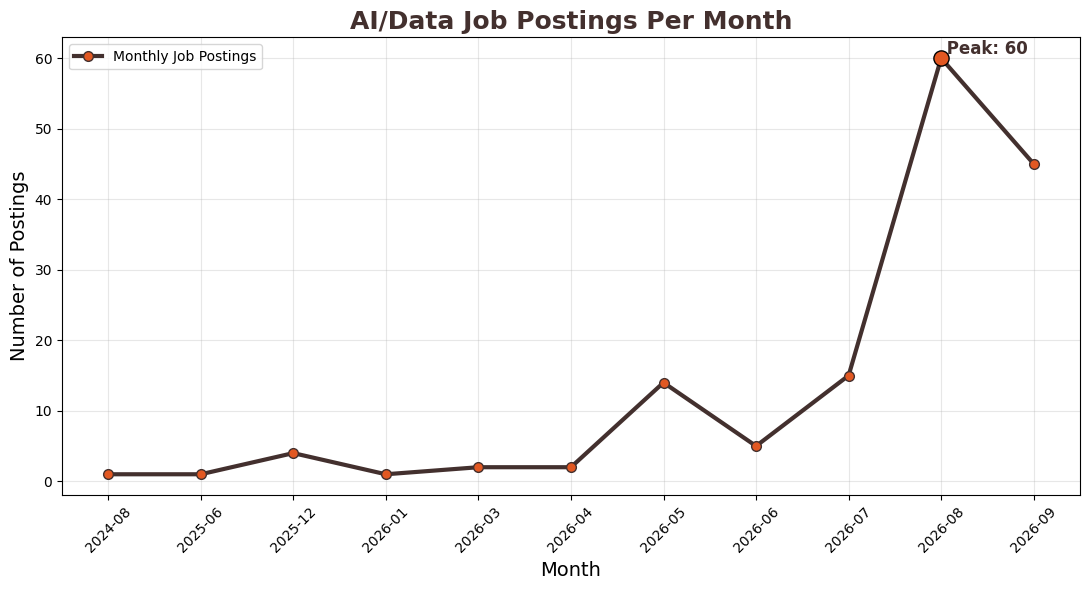

In [14]:
import matplotlib.pyplot as plt

# Convert dates
adzuna_df['created'] = pd.to_datetime(adzuna_df['created'], errors='coerce')

# Extract month
adzuna_df['month'] = adzuna_df['created'].dt.to_period('M')

# Monthly job count
monthly_counts = adzuna_df.groupby('month').size()

plt.figure(figsize=(11,6))

# Main line plot
plt.plot(
    monthly_counts.index.astype(str),
    monthly_counts.values,
    color=old_burgundy,
    linewidth=3,
    marker='o',
    markersize=7,
    markerfacecolor=terracotta,
    label="Monthly Job Postings"
)

# Highlight peak month
peak_month = monthly_counts.idxmax()
peak_value = monthly_counts.max()

plt.scatter(
    str(peak_month),
    peak_value,
    color=terracotta,
    s=120,
    edgecolor='black',
    zorder=5
)

plt.text(
    str(peak_month),
    peak_value,
    f" Peak: {peak_value}",
    fontsize=12,
    color=old_burgundy,
    ha='left',
    va='bottom',
    fontweight="bold"
)

plt.title("AI/Data Job Postings Per Month", fontsize=18, color=old_burgundy, fontweight="bold")
plt.xlabel("Month", fontsize=14)
plt.ylabel("Number of Postings", fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Question 2: Which AI/Data skills appear most often in job descriptions?

#### Answer

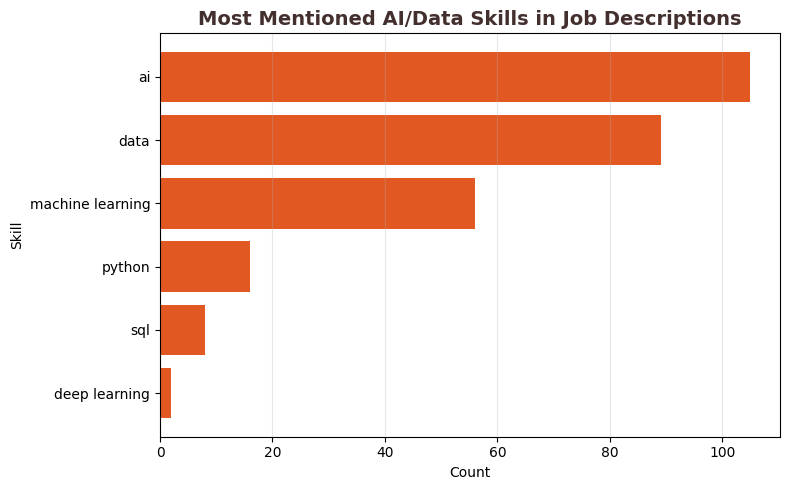

In [15]:
import matplotlib.pyplot as plt

# Pick simple skills taught and used in class examples
keywords = ["python", "machine learning", "ai", "data", "deep learning", "sql"]

# "ai" is counted as a standalone term so it does not fire inside "available",
# "training" or "maintain". Every other keyword keeps plain substring matching.
patterns = {"ai": r"\bai\b"}

skill_counts = {}

# Loop through each keyword and count how often it appears
for word in keywords:
    skill_counts[word] = adzuna_df['description'].str.lower().str.contains(patterns.get(word, word)).sum()

# Convert dictionary → DataFrame for easy plotting
skills_df = pd.DataFrame.from_dict(skill_counts, orient='index', columns=['count'])

skills_df = skills_df.sort_values('count')

plt.figure(figsize=(8,5))
plt.barh(skills_df.index, skills_df['count'], color=terracotta)

plt.title("Most Mentioned AI/Data Skills in Job Descriptions", fontsize=14, fontweight='bold', color="#43302E")
plt.xlabel("Count")
plt.ylabel("Skill")
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Question 3: What are the top 10 most popular developer skills on StackOverflow?

#### Answer

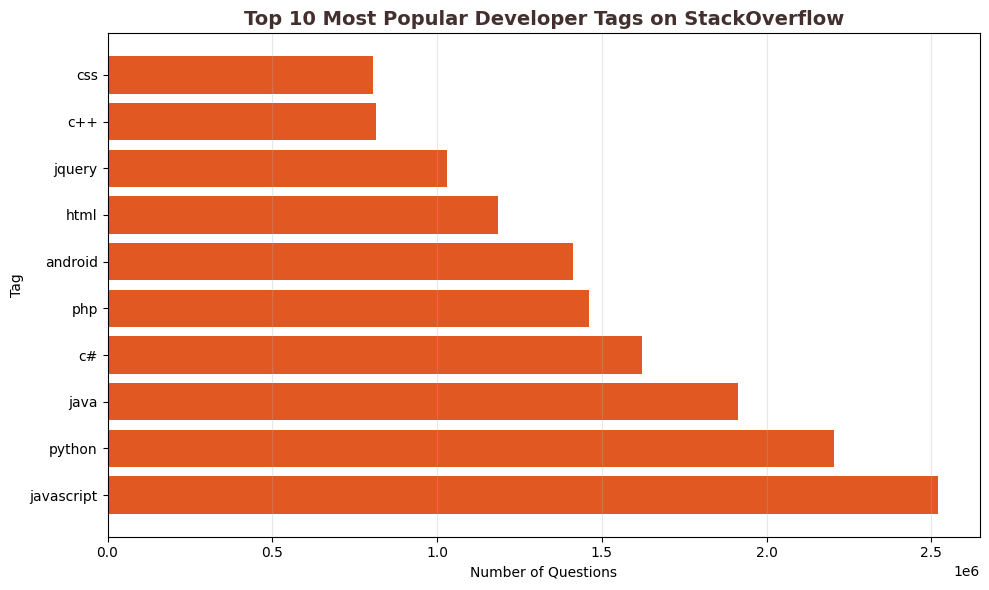

In [16]:
import matplotlib.pyplot as plt

# Sort tags by question_count and get the top 10
top10_tags = stackoverflow_df.sort_values(by='question_count', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top10_tags['tag_name'], top10_tags['question_count'], color=terracotta)
plt.title("Top 10 Most Popular Developer Tags on StackOverflow",
          fontsize=14, fontweight='bold', color="#43302E")
plt.xlabel("Number of Questions")
plt.ylabel("Tag")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Question 4: What is the salary distribution for AI/Data roles?

#### Answer

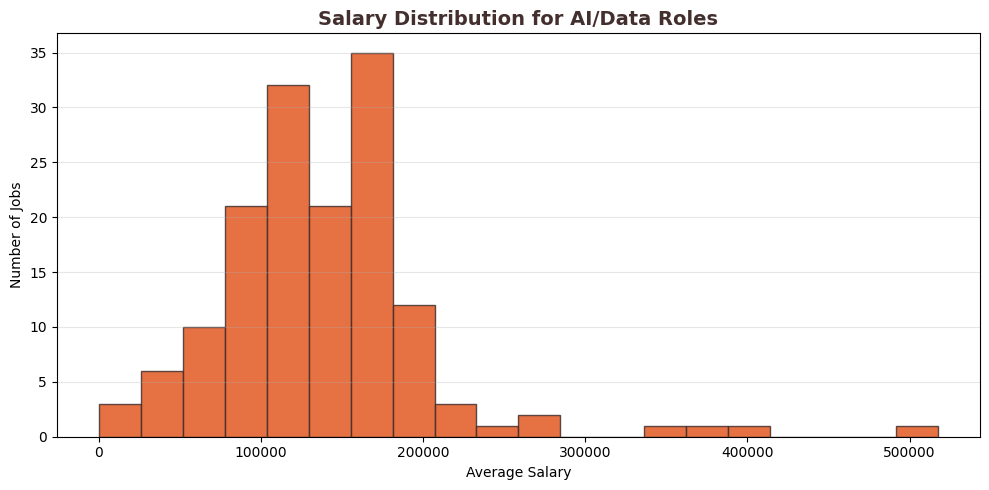

In [17]:
import matplotlib.pyplot as plt

# Calculate average salary for each posting
adzuna_df['salary_avg'] = (adzuna_df['salary_min'] + adzuna_df['salary_max']) / 2

# Filter out missing/zero salaries
valid_salaries = adzuna_df[adzuna_df['salary_avg'] > 0]['salary_avg']

plt.figure(figsize=(10,5))
plt.hist(valid_salaries, bins=20, color=terracotta, alpha=0.85, edgecolor=old_burgundy)

plt.title("Salary Distribution for AI/Data Roles", fontsize=14, fontweight="bold", color=old_burgundy)
plt.xlabel("Average Salary")
plt.ylabel("Number of Jobs")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Question 5: Which cities show the highest concentration of AI jobs?

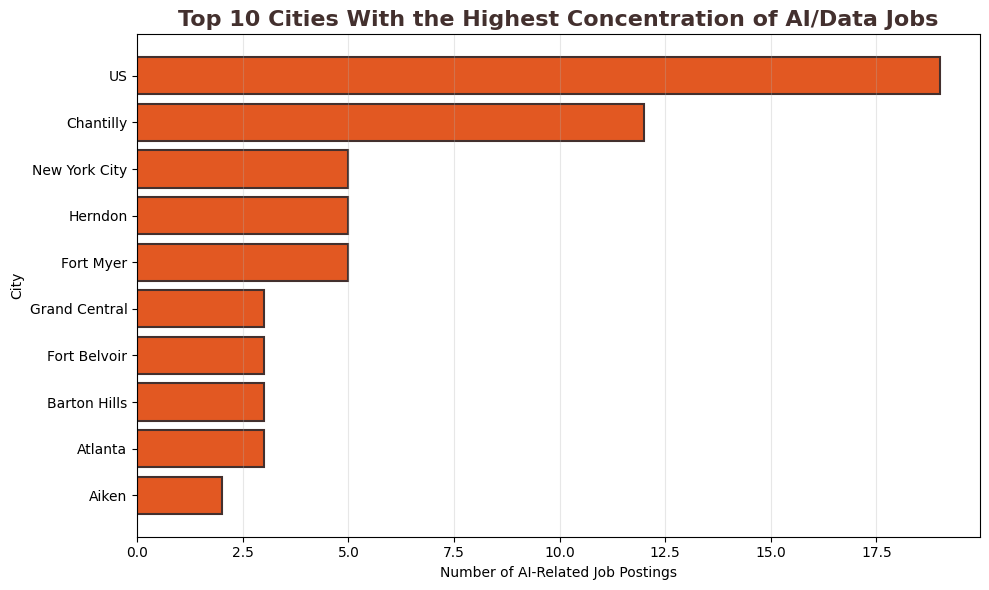

In [18]:
import matplotlib.pyplot as plt

# Clean location data
# Some rows may have missing location — drop them
adzuna_df['location'] = adzuna_df['location'].fillna("Unknown")

# Extract city name (usually the FIRST part before comma)
adzuna_df['city'] = adzuna_df['location'].astype(str).apply(lambda x: x.split(",")[0])

# Count jobs per city
city_counts = adzuna_df['city'].value_counts().head(10)   # Top 10 cities

plt.figure(figsize=(10,6))

plt.barh(
    city_counts.index[::-1],
    city_counts.values[::-1],
    color=terracotta,
    edgecolor=old_burgundy,
    linewidth=1.5
)

plt.title("Top 10 Cities With the Highest Concentration of AI/Data Jobs",
          fontsize=16, fontweight='bold', color=old_burgundy)

plt.xlabel("Number of AI-Related Job Postings")
plt.ylabel("City")

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

##D4. Summary of key findings

*Scope note: these findings describe one live snapshot — 150 US Adzuna postings and the top 100 Stack Overflow tags, as saved in the run above. Both APIs are live, so re-running produces different numbers. No statistical tests were performed. Phase IV answers the same five questions with refined visualizations.*

* **79.3% of the 150 postings (119 of 150) matched at least one term in the AI keyword indicator.** The indicator matches the short tokens `ai` and `ml` on word boundaries, so it does not fire inside "available", "training", "html" or "xml".
* **Postings cluster heavily in the most recent months.** 120 of 150 (80.0%) were created in July–September 2026, with August 2026 the largest single month at 60. The rest trail back sparsely to August 2024. This reflects how the endpoint works — currently-listed postings only — and is not evidence of growth, seasonality, or a hiring cycle.
* **Generic AI/data vocabulary dominates named tools.** Across the 150 descriptions: `ai` 105, `data` 89, `machine learning` 56, then a sharp drop to `python` 16, `sql` 8 and `deep learning` 2. Because descriptions are truncated to roughly 500 characters, the tool-level counts are best read as a floor rather than true demand.
* **Salaries concentrate between roughly \$85k and \$205k**, with the heaviest bin around \$165k–\$190k and a thin tail extending past \$400k. Part of Adzuna's salary data is model-predicted, so this mixes stated and estimated pay.
* **The location breakdown is locality-level, not metro-level.** The largest bucket is the unresolved label "US" (19), then Chantilly (12), followed by New York City, Herndon and Fort Myer at 5 each. Several top entries sit in the Northern Virginia / DC area, but at these counts the ranking should not be generalized.
* **Stack Overflow's most-asked tags are general-purpose languages,** not AI-specific tools: javascript (2.52M), python (2.20M), java (1.91M), c# (1.62M). These are all-time cumulative counts with no date attached, so they cannot be compared against the posting timeline.

### Limitations

* **Adzuna data is a live snapshot.** The `/search` endpoint returns currently-listed postings, so recent months are fuller by construction and the same query re-run later returns different postings.
* **Descriptions are truncated.** Adzuna returns roughly the first 500 characters of each posting, so named tools appearing deeper in a requirements section are undercounted.
* **Stack Overflow tag counts are cumulative and undated.** They are all-time question totals and cannot show change over time.
* **The two datasets are analyzed side by side, never joined.** No cross-source correlation is claimed or tested, and no statistical tests were performed.
* **Salary values mix posted and predicted pay.** Adzuna flags part of its salary data as model-predicted rather than employer-stated.
* **Location counts are locality-level.** Values resolve to granular Adzuna place names rather than metro areas, so they should not be read as a national hiring map.


##D5 Further research

* Collect more time periods to detect long-term patterns or seasonality.
* Compare cities or states to find AI job hotspots.
* Analyze salary patterns across skills or job titles.
* Use simple text analysis (NLP) to categorize job titles and responsibilities.
* Compare employer skill demand with developer skill supply in more depth.
* Add additional job-market APIs to build a multi-source dataset for stronger conclusions.
